In [1]:
import os
import cv2
import json
import torch

import numpy as np
import supervision as sv

from transformers import (
    AutoModelForCausalLM,
    AutoProcessor,
)
from tqdm import tqdm
from peft import LoraConfig, get_peft_model
from PIL import Image
import random

In [3]:
! nvidia-smi

Tue Feb 11 21:54:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.14                 Driver Version: 566.14         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   52C    P2             58W /  320W |    5979MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
CHECKPOINT = "model_checkpoints/epoch_3"
REVISION = 'refs/pr/10'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TORCH_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

model = AutoModelForCausalLM.from_pretrained(CHECKPOINT, trust_remote_code=True, revision=REVISION).to(DEVICE)
processor = AutoProcessor.from_pretrained(CHECKPOINT, trust_remote_code=True, revision=REVISION)

Florence2LanguageForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


In [4]:
config = LoraConfig(
    r=8,
    lora_alpha=8,
    target_modules=["q_proj", "o_proj", "k_proj", "v_proj", "linear", "Conv2d", "lm_head", "fc2"],
    task_type="CAUSAL_LM",
    lora_dropout=0.05,
    bias="none",
    inference_mode=False,
    use_rslora=True,
    init_lora_weights="gaussian",
    revision=REVISION
)

peft_model = get_peft_model(model, config)

In [5]:
adapter_name = "default"
peft_model.load_adapter(CHECKPOINT, adapter_name)

<All keys matched successfully>

In [6]:
peft_model.print_trainable_parameters()

trainable params: 4,133,576 || all params: 826,827,464 || trainable%: 0.4999


In [7]:
peft_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Florence2ForConditionalGeneration(
      (vision_tower): DaViT(
        (convs): ModuleList(
          (0): ConvEmbed(
            (proj): Conv2d(3, 256, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
            (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          )
          (1): ConvEmbed(
            (proj): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          )
          (2): ConvEmbed(
            (proj): Conv2d(512, 1024, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          )
          (3): ConvEmbed(
            (proj): Conv2d(1024, 2048, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            (norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          )
        )
        (blocks): ModuleList(
   

In [8]:
from PIL import Image, ImageDraw

In [51]:
image = Image.open('test/0b1c5d2fa34223ffa2c0c290f09b9ea4.JPG')

In [52]:
def run_example(task_prompt, text_input=None):
    if text_input is None:
        prompt = task_prompt
    else:
        prompt = task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(DEVICE)
    generated_ids = peft_model.generate(
      input_ids=inputs["input_ids"].cuda(),
      pixel_values=inputs["pixel_values"].cuda(),
      max_new_tokens=2048,
      early_stopping=False,
      do_sample=False,
      num_beams=4,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(
        generated_text, 
        task=task_prompt, 
        image_size=(image.width, image.height)
    )

    return parsed_answer

In [53]:
from PIL import Image, ImageDraw, ImageFont 
import random
import numpy as np

colormap = ['blue','orange','green','purple','brown','pink','gray','olive','cyan','red',
            'lime','indigo','violet','aqua','magenta','coral','gold','tan','skyblue']

def draw_polygons(image, prediction, fill_mask=False):  
    draw = ImageDraw.Draw(image)  
    scale = 1  
      
    for polygons, label in zip(prediction['polygons'], prediction['labels']):  
        color = random.choice(colormap)  
        fill_color = random.choice(colormap) if fill_mask else None  
          
        for _polygon in polygons:  
            _polygon = np.array(_polygon).reshape(-1, 2)  
            if len(_polygon) < 3:  
                print('Invalid polygon:', _polygon)  
                continue  
              
            _polygon = (_polygon * scale).reshape(-1).tolist()  
              
            if fill_mask:  
                draw.polygon(_polygon, outline=color, fill=fill_color)  
            else:  
                draw.polygon(_polygon, outline=color)  
              
            draw.text((_polygon[0] + 8, _polygon[1] + 2), label, fill=color)  
    display(image)

In [54]:
task_prompt = '<REGION_TO_SEGMENTATION>'
results = run_example(task_prompt, text_input="animal")

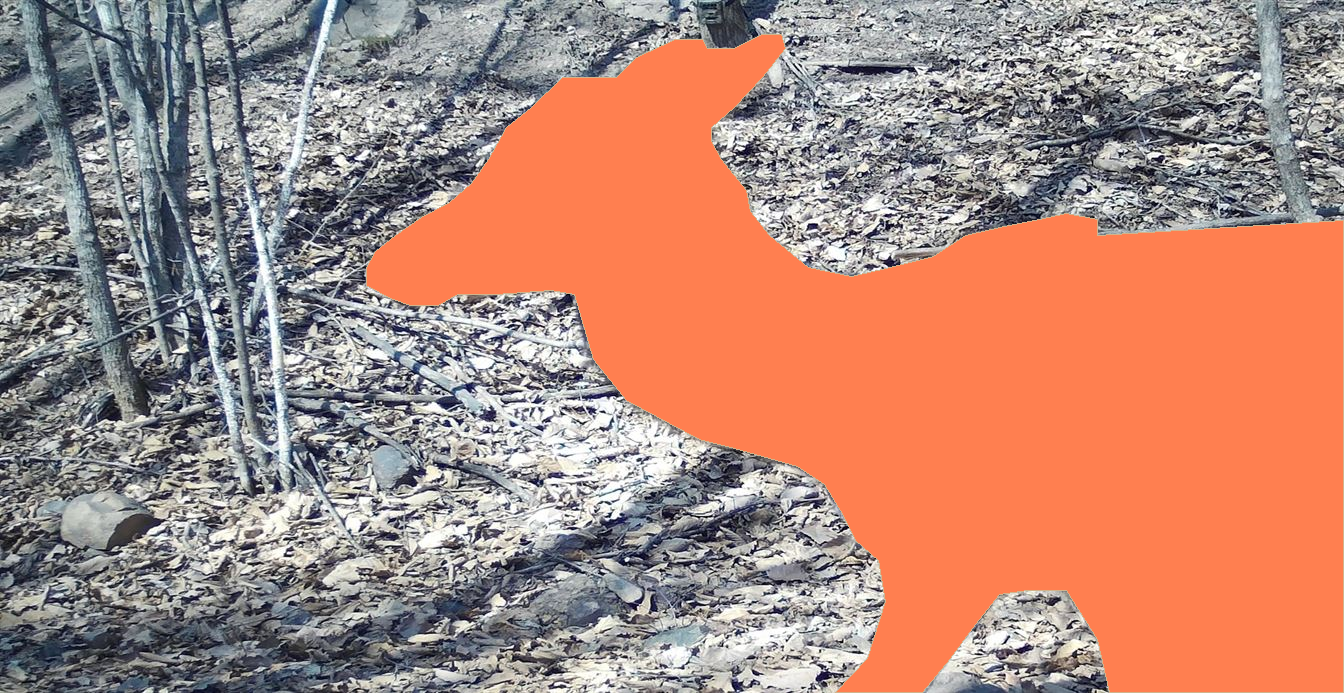

In [55]:
import copy

output_image = copy.deepcopy(image)
draw_polygons(output_image, results['<REGION_TO_SEGMENTATION>'], fill_mask=True)  

</s><s><s><s>animal<loc_117><loc_171><loc_567><loc_998></s>
{'<OD>': {'bboxes': [[157.9199981689453, 118.84950256347656, 762.719970703125, 691.9605102539062]], 'labels': ['animal']}}


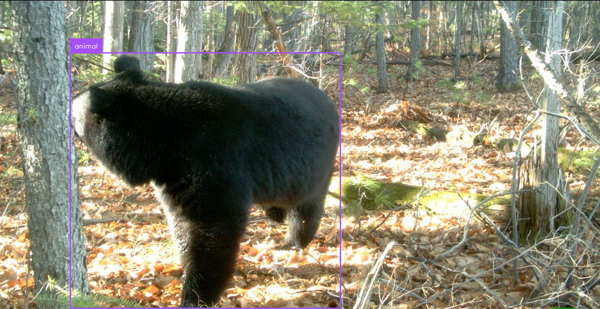

In [56]:
image = Image.open('test/0aeb703a3d4f784edfe05459b99b4b19.JPG')
task = "<OD>"
text = "<OD>"

inputs = processor(text=text, images=image, return_tensors="pt").to(DEVICE)
generated_ids = peft_model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=1024,
    num_beams=3
)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
print(generated_text)
response = processor.post_process_generation(generated_text, task=task, image_size=(image.width, image.height))
print(response)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

bounding_box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

image = bounding_box_annotator.annotate(image, detections)
image = label_annotator.annotate(image, detections)
image.thumbnail((600, 600))
image

In [57]:
from ultralytics import SAM, YOLO
import pycocotools.mask as mask_util
from PIL import Image, ImageDraw, ImageFont

In [ ]:
EXAMPLE_IMAGE_PATH = "test"
OUTPUT_DIRECTORY = "besty"
SUBMISSION_PATH = os.path.join(OUTPUT_DIRECTORY, "submission_z.json")

if not os.path.exists(OUTPUT_DIRECTORY):
    os.makedirs(OUTPUT_DIRECTORY)

if not os.path.exists(SUBMISSION_PATH):
    with open(SUBMISSION_PATH, 'w') as f:
        json.dump([], f)

os.environ['YOLO_VERBOSE'] = 'False'

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAM_MODEL_PATH = "sam2.1_l.pt"
YOLO_MODEL_PATH = "best.pt"

if not os.path.exists(SAM_MODEL_PATH):
    raise FileNotFoundError(f"SAM model file not found: {SAM_MODEL_PATH}")

if not os.path.exists(YOLO_MODEL_PATH):
    raise FileNotFoundError(f"YOLO model file not found: {YOLO_MODEL_PATH}")

sam_model = SAM(SAM_MODEL_PATH).to(DEVICE)
yolo_model = YOLO(YOLO_MODEL_PATH, verbose=False).to(DEVICE)

In [59]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l_channel)
    enhanced_lab = cv2.merge((cl, a_channel, b_channel))
    enhanced_img = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
    denoised_img = cv2.bilateralFilter(enhanced_img, d=9, sigmaColor=75, sigmaSpace=75)
    normalized_img = cv2.normalize(denoised_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    return normalized_img

# Основной сабмишен

In [60]:
def process_and_segment_images(image_folder):
    font = ImageFont.load_default()
    with open(SUBMISSION_PATH, 'w') as f:
        f.write('[]')

    for filename in tqdm(os.listdir(image_folder), desc="Processing images"):
        if filename.endswith(".JPG"):
            submissions = []
            image_path = os.path.join(image_folder, filename)
            image = Image.open(image_path).convert("RGBA")
            width, height = image.size
            task = "<OD>"
            text = "<OD>"

            inputs = processor(text=text, images=image.convert("RGB"), return_tensors="pt").to(DEVICE)
            generated_ids = peft_model.generate(
                input_ids=inputs["input_ids"],
                pixel_values=inputs["pixel_values"],
                max_new_tokens=1024,
                num_beams=3
            )
            generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
            response = processor.post_process_generation(generated_text, task=task, image_size=(width, height))
            detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

            bounding_boxes = detections.xyxy
            detections.bboxes = bounding_boxes 

            bounding_box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
            label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

            image = bounding_box_annotator.annotate(image, detections)
            image = label_annotator.annotate(image, detections)

            image_sam = preprocess_image(image_path)

            if len(bounding_boxes) > 0:
                results = sam_model(image_sam, bboxes=bounding_boxes)
                for i, (detection, mask) in enumerate(zip(detections.data['class_name'], results)):
                    if hasattr(mask, 'masks') and mask.masks is not None:
                        masks = mask.masks.data

                        for mask_idx in range(masks.shape[0]):
                            mask = masks[mask_idx].cpu().numpy()

                            if mask.shape != image.size[::-1]:
                                mask = np.resize(mask, image.size[::-1])

                            colored_mask = Image.new("RGBA", image.size)
                            random_color = np.random.rand(3)
                            alpha = 0.5

                            for x in range(mask.shape[1]):
                                for y in range(mask.shape[0]):
                                    if mask[y, x] > 0:
                                        colored_mask.putpixel((x, y), (
                                            int(random_color[0] * 255),
                                            int(random_color[1] * 255),
                                            int(random_color[2] * 255),
                                            int(255 * alpha)
                                        ))

                            image = Image.alpha_composite(image, colored_mask)

                            rle = mask_util.encode(np.asfortranarray(mask))
                            rle['counts'] = rle['counts'].decode('utf-8')

                            label = detection if isinstance(detection, str) else "Object"
                            draw = ImageDraw.Draw(image)
                            draw.text((bounding_boxes[i][0], bounding_boxes[i][1]), label, fill="white", font=font)

                            submission_entry = {
                                "image_name": filename,
                                "category_id": 0,
                                "bbox": bounding_boxes[i].tolist(),
                                "score": 1.0,
                                "segmentation": {
                                    "size": list(mask.shape[::1]),
                                    "counts": rle['counts']
                                }
                            }
                            submissions.append(submission_entry)

            else:
                results_yolo = yolo_model(image_path, conf=0.5)
                bboxes_yolo = results_yolo[0].boxes
                bboxes_yolo_np = bboxes_yolo.xyxy.cpu().numpy() if bboxes_yolo else np.array([])

                if bboxes_yolo_np.size > 0:
                    results = sam_model(image_sam, bboxes=bboxes_yolo_np)
                    for i, mask in enumerate(results):
                        if hasattr(mask, 'masks') and mask.masks is not None:
                            masks = mask.masks.data

                            for mask_idx in range(masks.shape[0]):
                                mask = masks[mask_idx].cpu().numpy()

                                if mask.shape != image.size[::-1]:
                                    mask = np.resize(mask, image.size[::-1])

                                colored_mask = Image.new("RGBA", image.size)
                                random_color = np.random.rand(3)
                                alpha = 0.5

                                for x in range(mask.shape[1]):
                                    for y in range(mask.shape[0]):
                                        if mask[y, x] > 0:
                                            colored_mask.putpixel((x, y), (
                                                int(random_color[0] * 255),
                                                int(random_color[1] * 255),
                                                int(random_color[2] * 255),
                                                int(255 * alpha)
                                            ))

                                image = Image.alpha_composite(image, colored_mask)

                                rle = mask_util.encode(np.asfortranarray(mask))
                                rle['counts'] = rle['counts'].decode('utf-8')

                                label = "Detected by YOLO"
                                draw = ImageDraw.Draw(image)
                                draw.text((bboxes_yolo_np[i][0], bboxes_yolo_np[i][1]), label, fill="white", font=font)

                                submission_entry = {
                                    "image_name": filename,
                                    "category_id": 0,
                                    "bbox": bboxes_yolo_np[i].tolist(),
                                    "score": 1.0,
                                    "segmentation": {
                                        "size": list(mask.shape[::1]),
                                        "counts": rle['counts']
                                    }
                                }
                                submissions.append(submission_entry)

            with open(SUBMISSION_PATH, 'r+') as f:
                data = json.load(f)
                data.extend(submissions)
                f.seek(0)
                json.dump(data, f, indent=4)

            output_path = os.path.join(OUTPUT_DIRECTORY, f"processed_{filename}")
            image.convert("RGB").save(output_path)

In [61]:
process_and_segment_images(EXAMPLE_IMAGE_PATH)

Processing images:   0%|          | 0/6 [00:00<?, ?it/s]


0: 1024x1024 1 0, 315.7ms
Speed: 9.3ms preprocess, 315.7ms inference, 6.1ms postprocess per image at shape (1, 3, 1024, 1024)


Processing images:  17%|█▋        | 1/6 [00:01<00:07,  1.51s/it]


0: 1024x1024 1 0, 114.0ms
Speed: 3.2ms preprocess, 114.0ms inference, 0.0ms postprocess per image at shape (1, 3, 1024, 1024)


Processing images:  33%|███▎      | 2/6 [00:02<00:05,  1.36s/it]

...

Processing images:  67%|██████▋   | 4/6 [00:05<00:02,  1.26s/it]


0: 1024x1024 1 0, 117.0ms
Speed: 1.5ms preprocess, 117.0ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 1024)


Processing images:  83%|████████▎ | 5/6 [00:06<00:01,  1.29s/it]


0: 1024x1024 1 0, 115.6ms
Speed: 3.0ms preprocess, 115.6ms inference, 1.0ms postprocess per image at shape (1, 3, 1024, 1024)


Processing images: 100%|██████████| 6/6 [00:07<00:00,  1.29s/it]


# 2 Сабмишен (только для тестов)

In [63]:
def process_and_segment_images(image_folder):
    font = ImageFont.load_default()
    submissions = []

    with open(SUBMISSION_PATH, 'w') as f:
        f.write('[]')
        
    for filename in tqdm(os.listdir(image_folder), desc="Processing images"):
        if filename.endswith(".JPG"):
            image_path = os.path.join(image_folder, filename)
            image = Image.open(image_path).convert("RGBA")
            width, height = image.size
            task = "<OD>"
            text = "<OD>"

            inputs = processor(text=text, images=image.convert("RGB"), return_tensors="pt").to(DEVICE)
            generated_ids = peft_model.generate(
                input_ids=inputs["input_ids"],
                pixel_values=inputs["pixel_values"],
                max_new_tokens=1024,
                num_beams=3
            )
            generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
            response = processor.post_process_generation(generated_text, task=task, image_size=(width, height))
            detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

            bounding_boxes = detections.xyxy
            detections.bboxes = bounding_boxes 

            if len(bounding_boxes) > 0:
                for bbox in bounding_boxes:
                    bbox_area = (bbox[2] - bbox[0]) * (bbox[3] - bbox[1])
                    image_area = width * height

                    if bbox_area / image_area > 0.97:
                        results_yolo = yolo_model(image_path, conf=0.5, verbose=False)
                        bboxes_yolo = results_yolo[0].boxes
                        bboxes_yolo_np = bboxes_yolo.xyxy.cpu().numpy() if bboxes_yolo else np.array([])

                        if bboxes_yolo_np.size > 0:
                            results = sam_model(image_path, bboxes=bboxes_yolo_np)
                            for i, mask in enumerate(results):
                                if hasattr(mask, 'masks') and mask.masks is not None:
                                    masks = mask.masks.data
                                    for mask_idx in range(masks.shape[0]):
                                        mask = masks[mask_idx].cpu().numpy()

                                        if mask.shape != (height, width):
                                            mask = np.resize(mask, (height, width))

                                        rle = mask_util.encode(np.asfortranarray(mask))
                                        rle['counts'] = rle['counts'].decode('utf-8')

                                        submission_entry = {
                                            "image_name": filename,
                                            "category_id": 0,
                                            "bbox": bboxes_yolo_np[i].tolist(),
                                            "score": 1.0,
                                            "segmentation": {
                                                "size": list(mask.shape),
                                                "counts": rle['counts']
                                            }
                                        }
                                        submissions.append(submission_entry)
                        break
                else:
                    results = sam_model(image_path, bboxes=bounding_boxes)
                    for i, (detection, mask) in enumerate(zip(detections.data['class_name'], results)):
                        if hasattr(mask, 'masks') and mask.masks is not None:
                            masks = mask.masks.data
                            for mask_idx in range(masks.shape[0]):
                                mask = masks[mask_idx].cpu().numpy()

                                if mask.shape != (height, width):
                                    mask = np.resize(mask, (height, width))

                                rle = mask_util.encode(np.asfortranarray(mask))
                                rle['counts'] = rle['counts'].decode('utf-8')

                                submission_entry = {
                                    "image_name": filename,
                                    "category_id": 0,
                                    "bbox": bounding_boxes[i].tolist(),
                                    "score": 1.0,
                                    "segmentation": {
                                        "size": list(mask.shape),
                                        "counts": rle['counts']
                                    }
                                }
                                submissions.append(submission_entry)
            else:
                results_yolo = yolo_model(image_path, conf=0.5, verbose=False)
                bboxes_yolo = results_yolo[0].boxes
                bboxes_yolo_np = bboxes_yolo.xyxy.cpu().numpy() if bboxes_yolo else np.array([])

                if bboxes_yolo_np.size > 0:
                    results = sam_model(image_path, bboxes=bboxes_yolo_np)
                    for i, mask in enumerate(results):
                        if hasattr(mask, 'masks') and mask.masks is not None:
                            masks = mask.masks.data
                            for mask_idx in range(masks.shape[0]):
                                mask = masks[mask_idx].cpu().numpy()

                                if mask.shape != (height, width):
                                    mask = np.resize(mask, (height, width))

                                rle = mask_util.encode(np.asfortranarray(mask))
                                rle['counts'] = rle['counts'].decode('utf-8')

                                submission_entry = {
                                    "image_name": filename,
                                    "category_id": 0,
                                    "bbox": bboxes_yolo_np[i].tolist(),
                                    "score": 1.0,
                                    "segmentation": {
                                        "size": list(mask.shape),
                                        "counts": rle['counts']
                                    }
                                }
                                submissions.append(submission_entry)

    with open(SUBMISSION_PATH, 'r+') as f:
        data = json.load(f)
        data.extend(submissions)
        f.seek(0)
        json.dump(data, f, indent=4)

In [64]:
process_and_segment_images(EXAMPLE_IMAGE_PATH)

Processing images:   0%|          | 0/6 [00:00<?, ?it/s]


image 1/1 c:\Users\Ivan\Desktop\Approved\test\0ae99c3dee6db6fbae77f4b5da3cf8c4.JPG: 1024x1024 1 0, 112.3ms
Speed: 3.0ms preprocess, 112.3ms inference, 0.0ms postprocess per image at shape (1, 3, 1024, 1024)


Processing images:  17%|█▋        | 1/6 [00:00<00:02,  2.24it/s]


image 1/1 c:\Users\Ivan\Desktop\Approved\test\0aeb703a3d4f784edfe05459b99b4b19.JPG: 1024x1024 1 0, 113.6ms
Speed: 3.0ms preprocess, 113.6ms inference, 0.0ms postprocess per image at shape (1, 3, 1024, 1024)


Processing images:  33%|███▎      | 2/6 [00:00<00:01,  2.45it/s]

...

Processing images:  67%|██████▋   | 4/6 [00:01<00:00,  2.61it/s]


image 1/1 c:\Users\Ivan\Desktop\Approved\test\0e9ef4b670f3e27273c6444ee44a1216.JPG: 1024x1024 1 0, 111.8ms
Speed: 2.5ms preprocess, 111.8ms inference, 0.0ms postprocess per image at shape (1, 3, 1024, 1024)


Processing images:  83%|████████▎ | 5/6 [00:01<00:00,  2.57it/s]


image 1/1 c:\Users\Ivan\Desktop\Approved\test\0ed22a4bf9ec0cc76993abcbd8f1e4e3.JPG: 1024x1024 1 0, 111.9ms
Speed: 3.0ms preprocess, 111.9ms inference, 0.0ms postprocess per image at shape (1, 3, 1024, 1024)


Processing images: 100%|██████████| 6/6 [00:02<00:00,  2.56it/s]
